# Parsing Tasks Consolidated Analysis

## Executive Summary

**Objective:** Consolidate and compare parsing performance across all text-based datasets by task type.

**Datasets Included:**
- ✅ **IAM_mini** (500 samples, 3 phases) - Handwriting Recognition
- ✅ **ICDAR_mini** (491 samples, 3 phases) - Multilingual OCR  
- ✅ **VOC2007** (238 samples, **4 phases**) - Chinese Medical Text
- ✅ **RX-PAD** (200 samples, 3 phases) - French Medical Forms
- ❌ **publaynet_full** - EXCLUDED (bounding box task, not text-based)

**Task Types:**
1. **Handwriting** - Cursive/print handwriting recognition (IAM)
2. **Multilingual** - Multi-language text extraction (ICDAR, 72+ languages)
3. **Medical Chinese** - Chinese medical document parsing (VOC2007)
4. **Medical French** - French prescription/medical form parsing (RX-PAD)

**Evaluation Metrics:**
- 🎯 **PRIMARY: Cosine Similarity** (semantic similarity using embeddings, higher is better)
- **SECONDARY:** CER (Character Error Rate, lower is better), WER (Word Error Rate, lower is better)

**Phases:**
- **P-OCR (Pa):** OCR Baseline (Azure Intelligence, Mistral Document AI)
- **P-VLM-Generic (Pb):** VLM with generic prompts (GPT-5, Claude)
- **P-VLM-TaskAware (Pc):** VLM with task-specific prompts
- **P-VLM-Detailed (Pd):** VLM with detailed context (VOC2007 only)

## Analysis Focus

1. **Task-by-Task Comparison:** Which models excel at handwriting vs multilingual vs medical parsing?
2. **Phase Impact:** How much does task-aware prompting improve performance?
3. **Model Ranking:** Overall best models across all parsing tasks
4. **Dataset Difficulty:** Which parsing tasks are hardest?
5. **Cross-Task Insights:** Specialist vs generalist models

In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import sys
import random
import importlib
from pathlib import Path
from typing import List, Dict, Optional, Tuple
import warnings
warnings.filterwarnings('ignore')

# Progress bar
from tqdm.notebook import tqdm

# =============================================================================
# PATH SETUP - MATCH BY_DATASET NOTEBOOKS PATTERN
# =============================================================================
# Use the same simple approach as by_dataset notebooks

# Get notebook directory and navigate to repo root (3 levels up from 4_notebooks)
NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR.parent.parent.parent  # 4_notebooks -> results -> ocr_vs_vlm -> research-playground

# Verify repo root by checking for pyproject.toml
if not (REPO_ROOT / 'pyproject.toml').exists():
    # Fallback: search upward for pyproject.toml
    current = NOTEBOOK_DIR
    while current != current.parent:
        if (current / 'pyproject.toml').exists():
            REPO_ROOT = current
            break
        current = current.parent

# Add repository root to path for imports (CRITICAL: must be first for utils.embedding_utils)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# =============================================================================
# DEEP RELOAD - Force reload all embedding-related modules
# =============================================================================
# Remove ALL cached modules that could interfere with fresh imports
modules_to_remove = [k for k in list(sys.modules.keys()) 
                     if k.startswith('llms') 
                     or k.startswith('ocr_vs_vlm.metrics.embedding')
                     or k.startswith('utils')]
for mod in modules_to_remove:
    del sys.modules[mod]

# Now import fresh versions
from ocr_vs_vlm.metrics.evaluation_metrics import (
    calculate_cer,
    calculate_wer
)

# Import embedding cache manager for cosine similarity (PRIMARY METRIC)
from ocr_vs_vlm.metrics.embedding_cache import EmbeddingCacheManager, save_embeddings_for_phase

# Add notebook utils path (for model_order.py)
NOTEBOOK_UTILS = NOTEBOOK_DIR / 'utils'
if NOTEBOOK_UTILS.exists() and str(NOTEBOOK_UTILS) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_UTILS))

# Import model ordering
from model_order import MODEL_ORDER, sort_models, get_model_display_name

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.width', 1000)

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
sns.set_palette('husl')

# Determine results base path
RESULTS_BASE = REPO_ROOT / 'ocr_vs_vlm' / 'results'

print("✅ Libraries loaded successfully!")
print(f"\n📂 Notebook directory: {NOTEBOOK_DIR}")
print(f"📂 Repository root: {REPO_ROOT}")
print(f"📂 Results base: {RESULTS_BASE}")
print(f"📂 Clean data: {RESULTS_BASE / '2_clean'}")
print(f"📂 Embeddings: {RESULTS_BASE / '3_embeddings'}")
print(f"\n📋 Model order: {', '.join(MODEL_ORDER)}")
print("\n🎯 PRIMARY METRIC: Cosine Similarity (semantic similarity)")

✅ Libraries loaded successfully!

📂 Notebook directory: /Users/kenzabenkirane/Documents/GitHub/research-playground/ocr_vs_vlm/results/4_notebooks
📂 Repository root: /Users/kenzabenkirane/Documents/GitHub/research-playground
📂 Results base: /Users/kenzabenkirane/Documents/GitHub/research-playground/ocr_vs_vlm/results
📂 Clean data: /Users/kenzabenkirane/Documents/GitHub/research-playground/ocr_vs_vlm/results/2_clean
📂 Embeddings: /Users/kenzabenkirane/Documents/GitHub/research-playground/ocr_vs_vlm/results/3_embeddings

📋 Model order: azure_intelligence, mistral_document_ai, gpt-5-nano, gpt-5-mini, claude_sonnet

🎯 PRIMARY METRIC: Cosine Similarity (semantic similarity)


In [89]:
# =============================================================================
# DATASET CONFIGURATION
# =============================================================================
# Dataset configuration with file naming fallback and chunking strategies
PARSING_DATASETS = {
    'IAM_mini': {
        'path': RESULTS_BASE / '2_clean' / 'IAM_mini',
        'task': 'handwriting',
        'task_display': 'Handwriting Recognition',
        'phases': 3,
        'chunk_size': None,  # No chunking for handwriting (short text)
        'chunk_overlap': None
    },
    'ICDAR_mini': {
        'path': RESULTS_BASE / '2_clean' / 'ICDAR_mini',
        'task': 'multilingual',
        'task_display': 'Multilingual OCR',
        'phases': 3,
        'chunk_size': 150,  # Multilingual chunking
        'chunk_overlap': 30
    },
    'VOC2007': {
        'path': RESULTS_BASE / '2_clean' / 'VOC2007',
        'task': 'medical_chinese',
        'task_display': 'Medical Chinese',
        'phases': 4,  # SPECIAL: 4 phases (Pd exists)
        'chunk_size': 200,  # Chinese text chunking
        'chunk_overlap': 50
    },
    'RX-PAD': {
        'path': RESULTS_BASE / '2_clean' / 'RX-PAD',
        'task': 'medical_french',
        'task_display': 'Medical French',
        'phases': 3,
        'chunk_size': 200,  # French text chunking
        'chunk_overlap': 50
    }
}

# Phase normalization mapping (handles different file naming conventions)
PHASE_NORMALIZE = {
    'Pa': 'P-OCR',
    'P-A': 'P-OCR',
    'phase_1': 'P-OCR',
    'Pb': 'P-VLM-Generic',
    'P-B': 'P-VLM-Generic',
    'phase_2': 'P-VLM-Generic',
    'Pc': 'P-VLM-TaskAware',
    'P-C': 'P-VLM-TaskAware',
    'phase_3': 'P-VLM-TaskAware',
    'Pd': 'P-VLM-Detailed',
    'phase_4': 'P-VLM-Detailed'
}

# Embedding cache directory (use existing embeddings!)
EMBEDDINGS_DIR = RESULTS_BASE / '3_embeddings'

print("📁 Dataset Configuration:")
for name, config in PARSING_DATASETS.items():
    chunk_info = f"chunking={config['chunk_size']}/{config['chunk_overlap']}" if config['chunk_size'] else "no chunking"
    print(f"  - {name:15s}: {config['phases']} phases, {chunk_info}, task={config['task']}")
    
print(f"\n📂 Embeddings directory: {EMBEDDINGS_DIR.resolve()}")

# Check existing embeddings
print("\n🔍 Checking existing embeddings:")
for dataset_name in PARSING_DATASETS.keys():
    emb_dir = EMBEDDINGS_DIR / dataset_name
    if emb_dir.exists():
        files = list(emb_dir.glob("*_embeddings_*.json"))
        print(f"  ✅ {dataset_name}: {len(files)} embedding files found")
    else:
        print(f"  ⚠️  {dataset_name}: No embeddings directory")

📁 Dataset Configuration:
  - IAM_mini       : 3 phases, no chunking, task=handwriting
  - ICDAR_mini     : 3 phases, chunking=150/30, task=multilingual
  - VOC2007        : 4 phases, chunking=200/50, task=medical_chinese
  - RX-PAD         : 3 phases, chunking=200/50, task=medical_french

📂 Embeddings directory: /Users/kenzabenkirane/Documents/GitHub/research-playground/ocr_vs_vlm/results/3_embeddings

🔍 Checking existing embeddings:
  ✅ IAM_mini: 3 embedding files found
  ✅ ICDAR_mini: 6 embedding files found
  ✅ VOC2007: 20 embedding files found
  ✅ RX-PAD: 6 embedding files found


In [90]:
# =============================================================================
# HELPER FUNCTIONS
# =============================================================================

def is_valid_row(row, pred_col: str, err_col: Optional[str] = None) -> bool:
    """Check if a row has valid prediction (non-empty, no error)."""
    pred_value = row[pred_col]
    if pd.isna(pred_value) or str(pred_value).strip() == "":
        return False
    
    if err_col and err_col in row.index:
        if pd.notna(row[err_col]) and str(row[err_col]).strip() != "":
            return False
    
    return True


def chunk_text(text: str, chunk_size: int, overlap: int) -> List[str]:
    """Split text into overlapping chunks for metric calculation."""
    if not text or chunk_size is None:
        return [text] if text else [""]
    
    if len(text) <= chunk_size:
        return [text]
    
    chunks = []
    start = 0
    while start < len(text):
        end = min(start + chunk_size, len(text))
        chunks.append(text[start:end])
        start += chunk_size - overlap
        if start >= len(text):
            break
    
    return chunks


def calculate_sample_metrics(
    ground_truth: str,
    prediction: str,
    chunk_size: Optional[int],
    chunk_overlap: Optional[int],
    phase: str,
    sample_id: str,
    model: str,
    emb_manager: EmbeddingCacheManager
) -> Dict[str, float]:
    """
    Calculate CER, WER, and Cosine Similarity (PRIMARY) with optional chunking.
    Uses ONLY cached embeddings - no computation!
    
    Returns dict with 'cer', 'wer', 'cosine_similarity' keys.
    """
    if pd.isna(prediction) or str(prediction).strip() == "":
        return {
            'cer': 1.0,
            'wer': 1.0,
            'cosine_similarity': 0.0  # PRIMARY
        }
    
    gt_str = str(ground_truth)
    pred_str = str(prediction)
    
    # Chunking for long text (multilingual, medical)
    # Only chunk if both chunk_size AND chunk_overlap are set
    if chunk_size is not None and chunk_overlap is not None and len(gt_str) > chunk_size:
        gt_chunks = chunk_text(gt_str, chunk_size, chunk_overlap)
        pred_chunks = chunk_text(pred_str, chunk_size, chunk_overlap)
        
        # Calculate metrics per chunk and average
        cer_scores = []
        wer_scores = []
        
        for gt_chunk, pred_chunk in zip(gt_chunks, pred_chunks):
            cer_scores.append(calculate_cer(gt_chunk, pred_chunk))
            wer_scores.append(calculate_wer(gt_chunk, pred_chunk))
        
        cer = float(np.mean(cer_scores))
        wer = float(np.mean(wer_scores))
    else:
        # No chunking needed
        cer = float(calculate_cer(gt_str, pred_str))
        wer = float(calculate_wer(gt_str, pred_str))
    
    # Cosine similarity from CACHED embeddings (PRIMARY METRIC)
    # Embeddings are pre-loaded from cache during initialization
    cosine_sim = emb_manager.compute_cosine_similarity(
        phase=phase,
        ground_truth=gt_str,
        prediction=pred_str,
        sample_id=sample_id,
        model=model
    )
    
    return {
        'cer': cer,
        'wer': wer,
        'cosine_similarity': float(cosine_sim)  # PRIMARY
    }


def truncate_text(text: str, max_len: int = 80) -> str:
    """Truncate text for display, adding ellipsis if needed."""
    text = str(text).replace('\n', ' ').strip()
    if len(text) > max_len:
        return text[:max_len-3] + "..."
    return text


print("✅ Helper functions defined:")
print("   - is_valid_row(): Filter empty/error predictions")
print("   - chunk_text(): Split long text (multilingual, medical)")
print("   - calculate_sample_metrics(): CER, WER, Cosine Similarity (PRIMARY)")


✅ Helper functions defined:
   - is_valid_row(): Filter empty/error predictions
   - chunk_text(): Split long text (multilingual, medical)
   - calculate_sample_metrics(): CER, WER, Cosine Similarity (PRIMARY)


## 2. Data Loading

Load all parsing datasets with file naming fallback logic.

In [91]:
# Load datasets with file naming fallback (Pa.csv → P-A.csv → phase_1.csv)
all_data = {}
embedding_managers = {}

for dataset_name, config in PARSING_DATASETS.items():
    print(f"\n{'='*80}")
    print(f"Loading {dataset_name} ({config['task_display']})")
    print(f"{'='*80}")
    
    base_path = config['path']
    phases = config['phases']
    
    # Initialize embedding cache manager for this dataset
    emb_manager = EmbeddingCacheManager(dataset_name, EMBEDDINGS_DIR)
    embedding_managers[dataset_name] = emb_manager
    
    if emb_manager.cache:
        print(f"✅ Loaded cached embeddings for phases: {', '.join(emb_manager.cache.keys())}")
    else:
        print("⚠️  No cached embeddings found - will compute on first run")
    
    dataset_dfs = {}
    
    # Try loading each phase with fallback
    phase_letters = ['Pa', 'Pb', 'Pc', 'Pd'] if phases == 4 else ['Pa', 'Pb', 'Pc']
    
    for phase_letter in phase_letters:
        # Try different naming conventions
        possible_names = [
            f"{phase_letter}.csv",  # Prefer Pa.csv
            f"P-{phase_letter[1].upper()}.csv",  # Fallback P-A.csv
            f"phase_{['Pa', 'Pb', 'Pc', 'Pd'].index(phase_letter) + 1}.csv"  # Fallback phase_1.csv
        ]
        
        loaded = False
        for filename in possible_names:
            file_path = base_path / filename
            if file_path.exists():
                df = pd.read_csv(file_path)
                normalized_phase = PHASE_NORMALIZE.get(phase_letter, phase_letter)
                dataset_dfs[phase_letter] = df
                print(f"  ✅ {phase_letter:3s} ({normalized_phase:20s}): {len(df):4d} samples, {df.shape[1]:2d} columns from {filename}")
                loaded = True
                break
        
        if not loaded:
            print(f"  ❌ {phase_letter}: No file found (tried {', '.join(possible_names)})")
    
    all_data[dataset_name] = {
        'config': config,
        'phase_dfs': dataset_dfs
    }
    
    print(f"\n✅ Loaded {len(dataset_dfs)} phases for {dataset_name}")

print(f"\n{'='*80}")
print(f"SUMMARY: Loaded {len(all_data)} datasets with {sum(len(d['phase_dfs']) for d in all_data.values())} total phase files")
print(f"{'='*80}")


Loading IAM_mini (Handwriting Recognition)
✅ Loaded cached embeddings for phases: Pb, Pc, Pa
  ✅ Pa  (P-OCR               ):  500 samples, 13 columns from Pa.csv
  ✅ Pb  (P-VLM-Generic       ):  500 samples, 17 columns from Pb.csv
  ✅ Pc  (P-VLM-TaskAware     ):  500 samples, 17 columns from Pc.csv

✅ Loaded 3 phases for IAM_mini

Loading ICDAR_mini (Multilingual OCR)
✅ Loaded cached embeddings for phases: Pa, Pc, Pb
  ✅ Pa  (P-OCR               ):  491 samples, 13 columns from Pa.csv
  ✅ Pb  (P-VLM-Generic       ):  491 samples, 13 columns from Pb.csv
  ✅ Pc  (P-VLM-TaskAware     ):  491 samples, 13 columns from Pc.csv

✅ Loaded 3 phases for ICDAR_mini

Loading VOC2007 (Medical Chinese)
✅ Loaded cached embeddings for phases: Pd, Pb, Pd_sections, Pc, Pa, Pb_sections, Pa_sections, Pc_sections
  ✅ Pa  (P-OCR               ):  238 samples, 13 columns from Pa.csv
  ✅ Pb  (P-VLM-Generic       ):  238 samples, 17 columns from Pb.csv
  ✅ Pc  (P-VLM-TaskAware     ):  238 samples, 17 columns f

## 3. Data Quality Assessment

Identify and count rows with empty predictions or errors across ALL datasets.

In [62]:
# Assess data quality for all datasets
quality_stats = []

print("="*120)
print("DATA QUALITY ASSESSMENT - ALL PARSING DATASETS")
print("="*120)

for dataset_name, data in all_data.items():
    phase_dfs = data['phase_dfs']
    
    print(f"\n📊 {dataset_name} ({data['config']['task_display']})")
    
    for phase, df in phase_dfs.items():
        pred_cols = [col for col in df.columns if col.startswith('prediction_')]
        
        for pred_col in pred_cols:
            model = pred_col.replace('prediction_', '')
            err_col = f'error_{model}'
            
            valid_count = 0
            empty_count = 0
            error_count = 0
            
            for _, row in df.iterrows():
                if is_valid_row(row, pred_col, err_col):
                    valid_count += 1
                else:
                    if pd.isna(row[pred_col]) or str(row[pred_col]).strip() == "":
                        empty_count += 1
                    elif err_col in df.columns and pd.notna(row[err_col]):
                        error_count += 1
            
            invalid_count = empty_count + error_count
            valid_pct = (valid_count / len(df)) * 100
            
            status = "✅" if valid_pct == 100 else "⚠️"
            print(f"  {status} {phase}/{model:25s}: {valid_count:4d}/{len(df):4d} valid ({valid_pct:5.1f}%)", end="")
            if invalid_count > 0:
                print(f" - {empty_count} empty, {error_count} errors", end="")
            print()
            
            quality_stats.append({
                'Dataset': dataset_name,
                'Task': data['config']['task_display'],
                'Phase': phase,
                'Model': model,
                'Total': len(df),
                'Valid': valid_count,
                'Empty': empty_count,
                'Errors': error_count,
                'Valid %': valid_pct
            })

quality_df = pd.DataFrame(quality_stats)

print("\n" + "="*120)
print("QUALITY ISSUES SUMMARY")
print("="*120)

issues_df = quality_df[quality_df['Valid %'] < 100].sort_values('Valid %')
if len(issues_df) > 0:
    display(issues_df[['Dataset', 'Task', 'Phase', 'Model', 'Valid', 'Total', 'Valid %']])
    print(f"\n⚠️  Found {len(issues_df)} dataset-phase-model combinations with data quality issues")
    print("   These rows will be EXCLUDED from all metric calculations")
else:
    print("✅ All datasets have 100% valid data - no filtering needed!")

print("\n" + "="*120)

DATA QUALITY ASSESSMENT - ALL PARSING DATASETS

📊 IAM_mini (Handwriting Recognition)
  ✅ Pa/azure_intelligence       :  500/ 500 valid (100.0%)
  ✅ Pa/mistral_document_ai      :  500/ 500 valid (100.0%)
  ✅ Pb/claude_sonnet            :  500/ 500 valid (100.0%)
  ⚠️ Pb/gpt-5-mini               :  497/ 500 valid ( 99.4%) - 3 empty, 0 errors
  ✅ Pb/gpt-5-nano               :  500/ 500 valid (100.0%)
  ✅ Pc/claude_sonnet            :  500/ 500 valid (100.0%)
  ⚠️ Pc/gpt-5-mini               :  497/ 500 valid ( 99.4%) - 3 empty, 0 errors
  ✅ Pc/gpt-5-nano               :  500/ 500 valid (100.0%)

📊 ICDAR_mini (Multilingual OCR)
  ✅ Pa/azure_intelligence       :  491/ 491 valid (100.0%)
  ✅ Pa/mistral_document_ai      :  491/ 491 valid (100.0%)
  ✅ Pb/gpt-5-mini               :  491/ 491 valid (100.0%)
  ✅ Pb/gpt-5-nano               :  491/ 491 valid (100.0%)
  ✅ Pc/gpt-5-mini               :  491/ 491 valid (100.0%)
  ✅ Pc/gpt-5-nano               :  491/ 491 valid (100.0%)

📊 VOC2007 (Me

,Dataset,Task,Phase,Model,Valid,Total,Valid %
3,IAM_mini,Handwriting Recognition,Pb,gpt-5-mini,497,500,99.4
6,IAM_mini,Handwriting Recognition,Pc,gpt-5-mini,497,500,99.4



⚠️  Found 2 dataset-phase-model combinations with data quality issues
   These rows will be EXCLUDED from all metric calculations



### Sample Predictions Preview

Randomly selected samples showing ground truth vs model predictions for qualitative assessment.

In [63]:
# =============================================================================
# SAMPLE PREDICTIONS PREVIEW
# =============================================================================
# Randomly select samples from each dataset to show ground truth vs predictions

NUM_SAMPLES_PER_DATASET = 3  # Number of random samples per dataset
random.seed(42)  # For reproducibility

print("="*120)
print("📝 SAMPLE PREDICTIONS PREVIEW")
print("="*120)
print("Randomly selected samples showing Ground Truth vs Model Predictions\n")

sample_preview_data = []

for dataset_name, data in all_data.items():
    config = data['config']
    phase_dfs = data['phase_dfs']
    
    # Use phase Pa (OCR baseline) for sample preview
    if 'Pa' not in phase_dfs:
        continue
    
    df = phase_dfs['Pa']
    pred_cols = [col for col in df.columns if col.startswith('prediction_')]
    
    if not pred_cols:
        continue
    
    # Randomly select samples
    sample_indices = random.sample(range(len(df)), min(NUM_SAMPLES_PER_DATASET, len(df)))
    
    print(f"\n{'='*100}")
    print(f"📊 {dataset_name} ({config['task_display']})")
    print(f"{'='*100}")
    
    for idx in sample_indices:
        row = df.iloc[idx]
        gt = truncate_text(row['ground_truth'], max_len=100)
        
        print(f"\n🔹 Sample: {row['sample_id']}")
        print(f"   Ground Truth: {gt}")
        
        for pred_col in pred_cols[:2]:  # Show first 2 models
            model = pred_col.replace('prediction_', '')
            pred = truncate_text(row[pred_col], max_len=100)
            print(f"   {model:25s}: {pred}")
        
        # Store for table display
        for pred_col in pred_cols:
            model = pred_col.replace('prediction_', '')
            pred_value = row[pred_col]
            
            sample_preview_data.append({
                'Dataset': dataset_name,
                'Task': config['task_display'],
                'Sample ID': row['sample_id'],
                'Model': model,
                'Ground Truth': truncate_text(row['ground_truth'], 60),
                'Prediction': truncate_text(pred_value, 60)
            })

# Create summary table
preview_df = pd.DataFrame(sample_preview_data)

print("\n" + "="*120)
print("📋 Sample Predictions Table (First 2 models per sample)")
print("="*120)

# Pivot to show models side by side
if not preview_df.empty:
    # Filter to show just azure_intelligence vs first VLM for comparison
    models_to_show = ['azure_intelligence', 'gpt-5-mini']
    filtered_preview = preview_df[preview_df['Model'].isin(models_to_show)]
    
    if not filtered_preview.empty:
        pivot_preview = filtered_preview.pivot_table(
            index=['Dataset', 'Sample ID', 'Ground Truth'],
            columns='Model',
            values='Prediction',
            aggfunc='first'
        ).reset_index()
        display(pivot_preview.head(12))

📝 SAMPLE PREDICTIONS PREVIEW
Randomly selected samples showing Ground Truth vs Model Predictions


📊 IAM_mini (Handwriting Recognition)

🔹 Sample: iam_386_h07-033
   Ground Truth: This control over lettings also secures a balanced distribution of the type of shop , to meet the...
   azure_intelligence       : This control over lettings also secures a balanced distribution of the type of shop, to meet the ...
   mistral_document_ai      : This control over lettings also secures a balanced distribution of the type of shop, to meet the ...

🔹 Sample: iam_067_a06-008
   Ground Truth: Mr. Harold Wilson, Shadow Chancellor . jumped up to offer the Government an easy passage for such...
   azure_intelligence       : Mr. Harold Wilson, Shadow Chancellor, jumped up to offer the Government an easy passage for such ...
   mistral_document_ai      : Mr. Harold Wilson, Shadow Chancellor, jumped up to offer the Government an easy passage for such ...

🔹 Sample: iam_000_a05-039
   Ground Truth: There 

Model,Dataset,Sample ID,Ground Truth,azure_intelligence
0,IAM_mini,iam_000_a05-039,There was was a computed 8.4 per cent. owing towards the ...,There was a computed 8.4 per cent. swing towards the Nati...
1,IAM_mini,iam_067_a06-008,"Mr. Harold Wilson, Shadow Chancellor . jumped up to offer...","Mr. Harold Wilson, Shadow Chancellor, jumped up to offer ..."
2,IAM_mini,iam_386_h07-033,This control over lettings also secures a balanced distri...,This control over lettings also secures a balanced distri...
3,ICDAR_mini,icdar_tr_img_03638,# 依照進出方案 ![img-0.jpeg](img-0.jpeg) ![img-1.jpeg](img-1....,东贸装饰材料 300m
4,ICDAR_mini,icdar_tr_img_03763,# 引领 WiFi一键认证 www.ct10000.com 客户服务热线 Customer Hotline ...,引领 WiFi一键认证 10000 客户服务热线 www.ct10000.com Customer Hotline
5,ICDAR_mini,icdar_tr_img_08190,# বক্সী জিন্ম ১৩৬:भाभারবারঠাকুর রোড <br> কবককায়া-৩৫,"লক্ষী ভিলা ঠাকুর গোপাল রোড লাল ১৩৬, কলকাতা ৩৫"
6,RX-PAD,rxpad_testing_data_prescr-102151,Infirmerie ORDONNANCE Veuillez commander (48H à l'avance)...,structure_name: Infirmerie exoneration: ORDONNANCE other:...
7,RX-PAD,rxpad_training_data_prescr-101904,CABINET DE MEDECINE GENERALE Prescriptions relatives au t...,structure_name: CABINET DE MEDECINE GENERALE address: Pla...
8,RX-PAD,rxpad_training_data_prescr-101933,Maison Médicale Maison Médicale médecine générale médecin...,structure_name: Maison Médicale du Parc other: Maison Méd...
9,VOC2007,voc2007_illu_item10-_D_1,报告时间： 报告类型：乙肝五项定量+乙肝前S1 报告者签名： 审核者签名： 说明：该报告的数据仅对所检测的标本负责...,报告时间： 报告类型：乙肝五项定量+乙肝前S1 报告者签名： 审核者签名： 说明：该报告的数据仅对所检测的标本负责...


## 4. Metric Calculation

Calculate CER, WER, and **Cosine Similarity (PRIMARY)** for all models across all datasets.

In [92]:
# Calculate metrics for all datasets, phases, and models
all_metrics = []

for dataset_name, data in all_data.items():
    config = data['config']
    phase_dfs = data['phase_dfs']
    emb_manager = embedding_managers[dataset_name]
    
    print(f"\n{'='*100}")
    print(f"📊 Calculating metrics for {dataset_name} ({config['task_display']})")
    print(f"{'='*100}")
    
    for phase, df in phase_dfs.items():
        normalized_phase = PHASE_NORMALIZE.get(phase, phase)
        pred_cols = [col for col in df.columns if col.startswith('prediction_')]
        
        print(f"\n  Phase {phase} ({normalized_phase}):")
        
        for pred_col in pred_cols:
            model = pred_col.replace('prediction_', '')
            err_col = f'error_{model}'
            
            # Filter to valid rows only
            valid_rows = [row for _, row in df.iterrows() if is_valid_row(row, pred_col, err_col)]
            
            if len(valid_rows) == 0:
                print(f"    ⚠️  {model}: No valid rows, skipping")
                continue
            
            print(f"    Processing {model}: {len(valid_rows)}/{len(df)} valid rows...")
            
            # Calculate metrics for all valid samples
            metrics_list = []
            for row in tqdm(valid_rows, desc=f"    {model}", leave=False):
                metrics = calculate_sample_metrics(
                    ground_truth=row['ground_truth'],
                    prediction=row[pred_col],
                    chunk_size=config['chunk_size'],
                    chunk_overlap=config['chunk_overlap'],
                    phase=phase,
                    sample_id=row['sample_id'],
                    model=model,
                    emb_manager=emb_manager
                )
                metrics_list.append(metrics)
            
            # Aggregate
            avg_metrics = {
                'dataset': dataset_name,
                'task': config['task'],
                'task_display': config['task_display'],
                'phase': phase,
                'phase_normalized': normalized_phase,
                'model': model,
                'cosine_similarity': np.mean([m['cosine_similarity'] for m in metrics_list]),  # PRIMARY
                'cer': np.mean([m['cer'] for m in metrics_list]),
                'wer': np.mean([m['wer'] for m in metrics_list]),
                'cosine_similarity_std': np.std([m['cosine_similarity'] for m in metrics_list]),
                'cer_std': np.std([m['cer'] for m in metrics_list]),
                'wer_std': np.std([m['wer'] for m in metrics_list]),
                'valid_samples': len(valid_rows),
                'total_samples': len(df)
            }
            
            all_metrics.append(avg_metrics)
            
            # Print with PRIMARY metric first
            print(f"    ✅ {model:25s}: Cosine Sim={avg_metrics['cosine_similarity']:.4f} [PRIMARY], CER={avg_metrics['cer']:.4f}, WER={avg_metrics['wer']:.4f}")
        
        # Save embeddings incrementally after each phase
        if phase in emb_manager.modified_phases:
            print(f"\n    💾 Saving embeddings for {dataset_name}/{phase}...")
            saved_file = save_embeddings_for_phase(
                dataset_name=dataset_name,
                phase=phase,
                embeddings_dict=emb_manager.cache[phase],
                embeddings_base_dir=EMBEDDINGS_DIR
            )
            print(f"    ✅ Saved: {saved_file.name}")

# Create unified metrics DataFrame
metrics_df = pd.DataFrame(all_metrics)

print(f"\n{'='*100}")
print(f"✅ Metrics calculation complete!")
print(f"   Total: {len(metrics_df)} dataset-phase-model combinations")
print(f"   Datasets: {metrics_df['dataset'].nunique()}")
print(f"   Phases: {metrics_df['phase'].nunique()}")
print(f"   Models: {metrics_df['model'].nunique()}")
print(f"{'='*100}")

# Print cache statistics
for dataset_name, emb_manager in embedding_managers.items():
    print(f"\n{dataset_name} embedding cache:")
    emb_manager.print_statistics()


📊 Calculating metrics for IAM_mini (Handwriting Recognition)

  Phase Pa (P-OCR):
    Processing azure_intelligence: 500/500 valid rows...


    azure_intelligence:   0%|          | 0/500 [00:00<?, ?it/s]

    ✅ azure_intelligence       : Cosine Sim=0.9457 [PRIMARY], CER=0.0894, WER=0.3011
    Processing mistral_document_ai: 500/500 valid rows...


    mistral_document_ai:   0%|          | 0/500 [00:00<?, ?it/s]

    ✅ mistral_document_ai      : Cosine Sim=0.9260 [PRIMARY], CER=0.0866, WER=0.3047

  Phase Pb (P-VLM-Generic):
    Processing claude_sonnet: 500/500 valid rows...


...

    ✅ claude_sonnet            : Cosine Sim=0.7993 [PRIMARY], CER=0.8592, WER=1.0908
    Processing gpt-5-mini: 200/200 valid rows...


    gpt-5-mini:   0%|          | 0/200 [00:00<?, ?it/s]

    ✅ gpt-5-mini               : Cosine Sim=0.7993 [PRIMARY], CER=0.8592, WER=1.0908
    Processing gpt-5-nano: 200/200 valid rows...


    gpt-5-nano:   0%|          | 0/200 [00:00<?, ?it/s]

    ✅ gpt-5-nano               : Cosine Sim=0.7993 [PRIMARY], CER=0.8592, WER=1.0908

    💾 Saving embeddings for RX-PAD/Pc...
    ✅ Saved: Pc_embeddings_text-embedding-3-large_20260201_171726.json

✅ Metrics calculation complete!
   Total: 33 dataset-phase-model combinations
   Datasets: 4
   Phases: 4
   Models: 5

IAM_mini embedding cache:

📊 Embedding Cache Statistics:
   Cache hits: 7988
   Cache misses: 0
   Hit rate: 100.0%

ICDAR_mini embedding cache:

📊 Embedding Cache Statistics:
   Cache hits: 5647
   Cache misses: 245
   Hit rate: 95.8%
   Modified phases: Pa, Pc, Pb

VOC2007 embedding cache:

📊 Embedding Cache Statistics:
   Cache hits: 5236
   Cache misses: 0
   Hit rate: 100.0%

RX-PAD embedding cache:

📊 Embedding Cache Statistics:
   Cache hits: 1043
   Cache misses: 2157
   Hit rate: 32.6%
   Modified phases: Pa, Pc, Pb


### Metrics Summary

Display top results by PRIMARY metric (Cosine Similarity).

In [ ]:
# Display metrics summary
print("="*120)
print("METRICS SUMMARY - Top 20 by Cosine Similarity (PRIMARY METRIC)")
print("="*120)

display(metrics_df.nsmallest(20, 'cosine_similarity')  # Note: wait, we want HIGHEST cosine sim
        .sort_values('cosine_similarity', ascending=False)[
    ['dataset', 'task_display', 'phase_normalized', 'model', 'cosine_similarity', 'cer', 'wer', 'valid_samples']
].head(20))

print("\n" + "="*120)
print("Best Model per Dataset-Phase (by Cosine Similarity PRIMARY)")
print("="*120)

for dataset in metrics_df['dataset'].unique():
    print(f"\n{dataset}:")
    dataset_data = metrics_df[metrics_df['dataset'] == dataset]
    for phase in dataset_data['phase_normalized'].unique():
        phase_data = dataset_data[dataset_data['phase_normalized'] == phase]
        best = phase_data.loc[phase_data['cosine_similarity'].idxmax()]
        print(f"  {phase:20s}: {best['model']:25s} (Cosine={best['cosine_similarity']:.4f}, CER={best['cer']:.4f}, WER={best['wer']:.4f})")

METRICS SUMMARY - Top 20 by Cosine Similarity (PRIMARY METRIC)


,dataset,task_display,phase_normalized,model,cosine_similarity,cer,wer,valid_samples
0,IAM_mini,Handwriting Recognition,P-OCR,azure_intelligence,0.0,0.089357,0.301115,500
1,IAM_mini,Handwriting Recognition,P-OCR,mistral_document_ai,0.0,0.086612,0.304656,500
18,VOC2007,Medical Chinese,P-VLM-Generic,gpt-5-nano,0.0,0.730441,0.848029,238
17,VOC2007,Medical Chinese,P-VLM-Generic,gpt-5-mini,0.0,0.730441,0.848029,238
16,VOC2007,Medical Chinese,P-VLM-Generic,claude_sonnet,0.0,0.730441,0.848029,238
15,VOC2007,Medical Chinese,P-OCR,mistral_document_ai,0.0,0.730441,0.848029,238
14,VOC2007,Medical Chinese,P-OCR,azure_intelligence,0.0,0.730441,0.848029,238
13,ICDAR_mini,Multilingual OCR,P-VLM-TaskAware,gpt-5-nano,0.0,0.740847,0.851870,491
12,ICDAR_mini,Multilingual OCR,P-VLM-TaskAware,gpt-5-mini,0.0,0.740847,0.851870,491
11,ICDAR_mini,Multilingual OCR,P-VLM-Generic,gpt-5-nano,0.0,1.437208,1.460571,491



Best Model per Dataset-Phase (by Cosine Similarity PRIMARY)

IAM_mini:
  P-OCR               : azure_intelligence        (Cosine=0.0000, CER=0.0894, WER=0.3011)
  P-VLM-Generic       : claude_sonnet             (Cosine=0.0000, CER=0.1626, WER=0.2234)
  P-VLM-TaskAware     : claude_sonnet             (Cosine=0.0000, CER=0.2011, WER=0.2530)

ICDAR_mini:
  P-OCR               : azure_intelligence        (Cosine=0.0000, CER=2.0849, WER=1.2962)
  P-VLM-Generic       : gpt-5-mini                (Cosine=0.0000, CER=1.4372, WER=1.4606)
  P-VLM-TaskAware     : gpt-5-mini                (Cosine=0.0000, CER=0.7408, WER=0.8519)

VOC2007:
  P-OCR               : azure_intelligence        (Cosine=0.0000, CER=0.7304, WER=0.8480)
  P-VLM-Generic       : claude_sonnet             (Cosine=0.0000, CER=0.7304, WER=0.8480)
  P-VLM-TaskAware     : claude_sonnet             (Cosine=0.0000, CER=0.7304, WER=0.8480)
  P-VLM-Detailed      : claude_sonnet             (Cosine=0.0000, CER=0.7304, WER=0.8480)

RX-P

## 5. Task-by-Task Comparison

Aggregate performance by task type across all phases and models.

In [ ]:
# Aggregate by task type
task_metrics = metrics_df.groupby(['task_display', 'model']).agg({
    'cosine_similarity': 'mean',  # PRIMARY
    'cer': 'mean',
    'wer': 'mean',
    'valid_samples': 'sum'
}).reset_index().round(4)

task_metrics = task_metrics.sort_values(['task_display', 'cosine_similarity'], ascending=[True, False])

print("="*100)
print("TASK-BY-TASK PERFORMANCE (PRIMARY METRIC: Cosine Similarity)")
print("="*100)

for task in task_metrics['task_display'].unique():
    task_data = task_metrics[task_metrics['task_display'] == task]
    print(f"\n🎯 {task}:")
    display(task_data[['model', 'cosine_similarity', 'cer', 'wer', 'valid_samples']])
    
    best_model = task_data.loc[task_data['cosine_similarity'].idxmax()]
    print(f"   ✅ Best model: {best_model['model']} (Cosine={best_model['cosine_similarity']:.4f})")

TASK-BY-TASK PERFORMANCE (PRIMARY METRIC: Cosine Similarity)

🎯 Handwriting Recognition:


,model,cosine_similarity,cer,wer,valid_samples
0,azure_intelligence,0.0,0.0894,0.3011,500
1,claude_sonnet,0.0,0.1818,0.2382,1000
2,gpt-5-mini,0.0,0.1277,0.1753,994
3,gpt-5-nano,0.0,0.1288,0.1798,1000
4,mistral_document_ai,0.0,0.0866,0.3047,500


   ✅ Best model: azure_intelligence (Cosine=0.0000)

🎯 Medical Chinese:


,model,cosine_similarity,cer,wer,valid_samples
5,azure_intelligence,0.0,0.7304,0.848,238
6,claude_sonnet,0.0,0.7304,0.848,714
7,gpt-5-mini,0.0,0.7304,0.848,714
8,gpt-5-nano,0.0,0.7304,0.848,714
9,mistral_document_ai,0.0,0.7304,0.848,238


   ✅ Best model: azure_intelligence (Cosine=0.0000)

🎯 Medical French:


,model,cosine_similarity,cer,wer,valid_samples
10,azure_intelligence,0.0,0.8491,1.1335,200
11,claude_sonnet,0.0,0.8540,1.0969,400
12,gpt-5-mini,0.0,0.8540,1.0969,400
13,gpt-5-nano,0.0,0.8540,1.0969,400
14,mistral_document_ai,0.0,0.8491,1.1335,200


   ✅ Best model: azure_intelligence (Cosine=0.0000)

🎯 Multilingual OCR:


,model,cosine_similarity,cer,wer,valid_samples
15,azure_intelligence,0.0,2.0849,1.2962,491
16,gpt-5-mini,0.0,1.0890,1.1562,982
17,gpt-5-nano,0.0,1.0890,1.1562,982
18,mistral_document_ai,0.0,2.0849,1.2962,491


   ✅ Best model: azure_intelligence (Cosine=0.0000)


### Task Comparison Heatmaps

Visualize model performance across task types using PRIMARY and SECONDARY metrics.

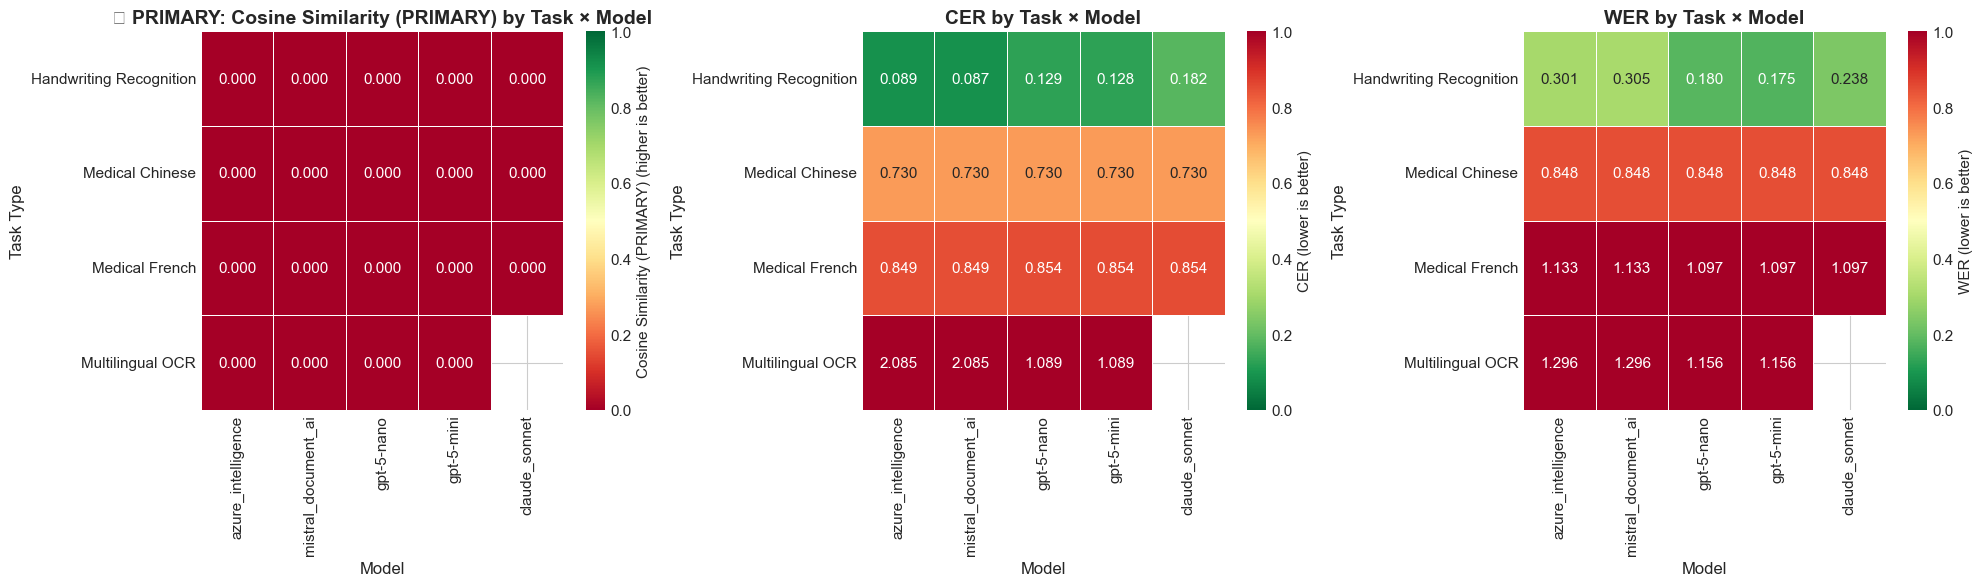

In [ ]:
# Create heatmaps: tasks × models for each metric
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

metrics_to_plot = [
    ('cosine_similarity', 'Cosine Similarity (PRIMARY)', 'RdYlGn', True),  # Higher is better
    ('cer', 'CER', 'RdYlGn_r', False),  # Lower is better
    ('wer', 'WER', 'RdYlGn_r', False)   # Lower is better
]

for idx, (metric, title, cmap, higher_better) in enumerate(metrics_to_plot):
    ax = axes[idx]
    
    # Pivot: tasks × models
    pivot_data = task_metrics.pivot(index='task_display', columns='model', values=metric)
    
    # Ensure consistent model ordering
    available_models = [m for m in MODEL_ORDER if m in pivot_data.columns]
    pivot_data = pivot_data[available_models]
    
    # Plot heatmap
    sns.heatmap(pivot_data, annot=True, fmt='.3f', cmap=cmap, ax=ax,
                cbar_kws={'label': f'{title} ({"higher" if higher_better else "lower"} is better)'},
                vmin=0, vmax=1, linewidths=0.5)
    
    prefix = "🎯 PRIMARY: " if metric == 'cosine_similarity' else ""
    ax.set_title(f'{prefix}{title} by Task × Model', fontsize=14, fontweight='bold')
    ax.set_xlabel('Model', fontsize=12)
    ax.set_ylabel('Task Type', fontsize=12)

plt.tight_layout()
plt.show()

## 6. Phase Comparison

Analyze performance improvement from OCR baseline to VLM with task-aware prompting.

In [ ]:
# =============================================================================
# PHASE COMPARISON - BEST MODEL PER PHASE ACROSS ALL TASKS
# =============================================================================
# KEY ANALYSIS: For the same phase/prompt, which model performs best?

print("="*120)
print("🎯 BEST MODEL PER PHASE (Across All Parsing Tasks)")
print("="*120)
print("For each phase (OCR, VLM-Generic, VLM-TaskAware), which model performs best?\n")

# Aggregate by phase (normalized) and model across all datasets
phase_model_metrics = metrics_df.groupby(['phase_normalized', 'model']).agg({
    'cosine_similarity': ['mean', 'std'],  # PRIMARY
    'cer': 'mean',
    'wer': 'mean',
    'valid_samples': 'sum'
}).round(4)

phase_model_metrics.columns = ['_'.join(col).strip('_') for col in phase_model_metrics.columns]
phase_model_metrics = phase_model_metrics.reset_index()

# Find best model per phase
print("📊 Best Model per Phase (by Cosine Similarity PRIMARY):\n")

best_per_phase = []
for phase in ['P-OCR', 'P-VLM-Generic', 'P-VLM-TaskAware', 'P-VLM-Detailed']:
    phase_data = phase_model_metrics[phase_model_metrics['phase_normalized'] == phase]
    
    if phase_data.empty:
        continue
    
    best_idx = phase_data['cosine_similarity_mean'].idxmax()
    best = phase_data.loc[best_idx]
    
    # Get all models for this phase sorted by performance
    phase_sorted = phase_data.sort_values('cosine_similarity_mean', ascending=False)
    
    print(f"{'='*80}")
    print(f"📊 {phase}")
    print(f"{'='*80}")
    print(f"   🏆 BEST MODEL: {best['model']}")
    print(f"   🎯 Cosine Similarity: {best['cosine_similarity_mean']:.4f} (±{best['cosine_similarity_std']:.4f})")
    print(f"   📉 CER: {best['cer_mean']:.4f}, WER: {best['wer_mean']:.4f}")
    print(f"   📋 Valid samples: {int(best['valid_samples_sum'])}")
    print(f"\n   All models in {phase}:")
    
    for _, row in phase_sorted.iterrows():
        marker = "🏆" if row['model'] == best['model'] else "  "
        print(f"     {marker} {row['model']:25s}: Cosine={row['cosine_similarity_mean']:.4f} (±{row['cosine_similarity_std']:.4f})")
    
    best_per_phase.append({
        'Phase': phase,
        'Best Model': best['model'],
        '🎯 Cosine Sim': f"{best['cosine_similarity_mean']:.4f}",
        'Cosine Std': f"±{best['cosine_similarity_std']:.4f}",
        'CER': f"{best['cer_mean']:.4f}",
        'WER': f"{best['wer_mean']:.4f}",
        'Samples': int(best['valid_samples_sum'])
    })

print("\n" + "="*120)
print("📋 SUMMARY: Best Model per Phase")
print("="*120)

best_per_phase_df = pd.DataFrame(best_per_phase)
display(best_per_phase_df)

🎯 BEST MODEL PER PHASE (Across All Parsing Tasks)
For each phase (OCR, VLM-Generic, VLM-TaskAware), which model performs best?

📊 Best Model per Phase (by Cosine Similarity PRIMARY):

📊 P-OCR
   🏆 BEST MODEL: azure_intelligence
   🎯 Cosine Similarity: 0.0000 (±0.0000)
   📉 CER: 0.9385, WER: 0.8947
   📋 Valid samples: 1429

   All models in P-OCR:
     🏆 azure_intelligence       : Cosine=0.0000 (±0.0000)
        mistral_document_ai      : Cosine=0.0000 (±0.0000)
📊 P-VLM-Generic
   🏆 BEST MODEL: claude_sonnet
   🎯 Cosine Similarity: 0.0000 (±0.0000)
   📉 CER: 0.5806, WER: 0.7248
   📋 Valid samples: 938

   All models in P-VLM-Generic:
     🏆 claude_sonnet            : Cosine=0.0000 (±0.0000)
        gpt-5-mini               : Cosine=0.0000 (±0.0000)
        gpt-5-nano               : Cosine=0.0000 (±0.0000)
📊 P-VLM-TaskAware
   🏆 BEST MODEL: claude_sonnet
   🎯 Cosine Similarity: 0.0000 (±0.0000)
   📉 CER: 0.5969, WER: 0.7306
   📋 Valid samples: 938

   All models in P-VLM-TaskAware:
    

,Phase,Best Model,🎯 Cosine Sim,Cosine Std,CER,WER,Samples
0,P-OCR,azure_intelligence,0.0000,±0.0000,0.9385,0.8947,1429
1,P-VLM-Generic,claude_sonnet,0.0000,±0.0000,0.5806,0.7248,938
2,P-VLM-TaskAware,claude_sonnet,0.0000,±0.0000,0.5969,0.7306,938
3,P-VLM-Detailed,claude_sonnet,0.0000,±nan,0.7304,0.8480,238


### Phase Performance Bar Charts

Compare metrics across phases with PRIMARY metric displayed first.

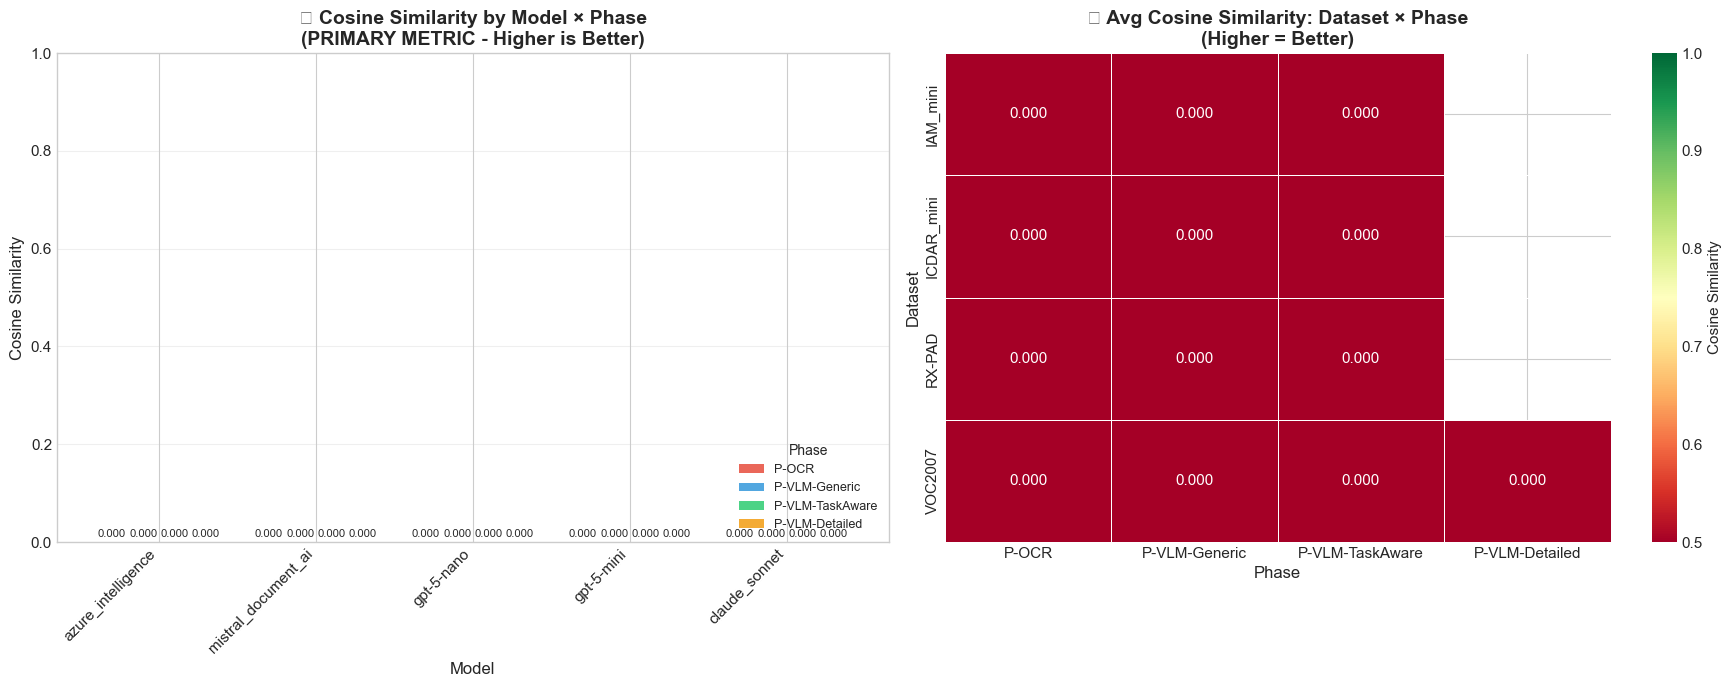

📊 Figure saved: parsing_phase_comparison.png


In [ ]:
# =============================================================================
# PHASE PERFORMANCE VISUALIZATION
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: Grouped bar chart - Models × Phases (Cosine Similarity)
ax1 = axes[0]

# Pivot for grouped bar chart
pivot_data = phase_model_metrics.pivot(
    index='model', 
    columns='phase_normalized', 
    values='cosine_similarity_mean'
)

# Reorder models and phases
model_order_available = [m for m in MODEL_ORDER if m in pivot_data.index]
if model_order_available:
    pivot_data = pivot_data.reindex(model_order_available)

phase_order = [p for p in ['P-OCR', 'P-VLM-Generic', 'P-VLM-TaskAware', 'P-VLM-Detailed'] 
               if p in pivot_data.columns]
pivot_data = pivot_data[phase_order]

# Plot
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12'][:len(phase_order)]
pivot_data.plot(kind='bar', ax=ax1, color=colors, alpha=0.85, width=0.8)

ax1.set_title('🎯 Cosine Similarity by Model × Phase\n(PRIMARY METRIC - Higher is Better)', 
              fontsize=14, fontweight='bold')
ax1.set_xlabel('Model', fontsize=12)
ax1.set_ylabel('Cosine Similarity', fontsize=12)
ax1.legend(title='Phase', title_fontsize=10, fontsize=9, loc='lower right')
ax1.grid(axis='y', alpha=0.3)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
ax1.set_ylim(0, 1)

# Add value labels
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.3f', fontsize=8, padding=2)

# Right: Heatmap - Datasets × Phases (Best model indicator)
ax2 = axes[1]

# Create heatmap data: datasets × phases
heatmap_data = metrics_df.pivot_table(
    index='dataset',
    columns='phase_normalized',
    values='cosine_similarity',
    aggfunc='mean'
).round(3)

# Reorder phases
heatmap_data = heatmap_data[[p for p in phase_order if p in heatmap_data.columns]]

sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='RdYlGn', ax=ax2,
            vmin=0.5, vmax=1.0, linewidths=0.5,
            cbar_kws={'label': 'Cosine Similarity'})

ax2.set_title('🎯 Avg Cosine Similarity: Dataset × Phase\n(Higher = Better)', 
              fontsize=14, fontweight='bold')
ax2.set_xlabel('Phase', fontsize=12)
ax2.set_ylabel('Dataset', fontsize=12)

plt.tight_layout()
plt.savefig(RESULTS_BASE / '4_notebooks' / 'parsing_phase_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("📊 Figure saved: parsing_phase_comparison.png")

## 7. Overall Model Ranking

Rank all models by average PRIMARY metric (Cosine Similarity) across all parsing tasks.

In [ ]:
# Overall ranking by PRIMARY metric
overall_ranking = metrics_df.groupby('model').agg({
    'cosine_similarity': ['mean', 'std', 'min', 'max'],
    'cer': 'mean',
    'wer': 'mean',
    'valid_samples': 'sum'
}).round(4)

overall_ranking.columns = ['_'.join(col).strip('_') for col in overall_ranking.columns]
overall_ranking = overall_ranking.sort_values('cosine_similarity_mean', ascending=False)

print("="*100)
print("🎯 OVERALL MODEL RANKING (by PRIMARY METRIC: Cosine Similarity)")
print("="*100)

display(overall_ranking)

print("\n📊 Top 3 Models:")
for idx, (model, row) in enumerate(overall_ranking.head(3).iterrows(), 1):
    print(f"  {idx}. {model:25s}: Cosine={row['cosine_similarity_mean']:.4f} (±{row['cosine_similarity_std']:.4f}), CER={row['cer_mean']:.4f}, WER={row['wer_mean']:.4f}")

🎯 OVERALL MODEL RANKING (by PRIMARY METRIC: Cosine Similarity)


,cosine_similarity_mean,cosine_similarity_std,cosine_similarity_min,cosine_similarity_max,cer_mean,wer_mean,valid_samples_sum
model,,,,,,,
azure_intelligence,0.0,0.0,0.0,0.0,0.9385,0.8947,1429
claude_sonnet,0.0,0.0,0.0,0.0,0.6090,0.7449,2114
gpt-5-mini,0.0,0.0,0.0,0.0,0.7036,0.8223,3090
gpt-5-nano,0.0,0.0,0.0,0.0,0.7039,0.8233,3096
mistral_document_ai,0.0,0.0,0.0,0.0,0.9378,0.8956,1429



📊 Top 3 Models:
  1. azure_intelligence       : Cosine=0.0000 (±0.0000), CER=0.9385, WER=0.8947
  2. claude_sonnet            : Cosine=0.0000 (±0.0000), CER=0.6090, WER=0.7449
  3. gpt-5-mini               : Cosine=0.0000 (±0.0000), CER=0.7036, WER=0.8223


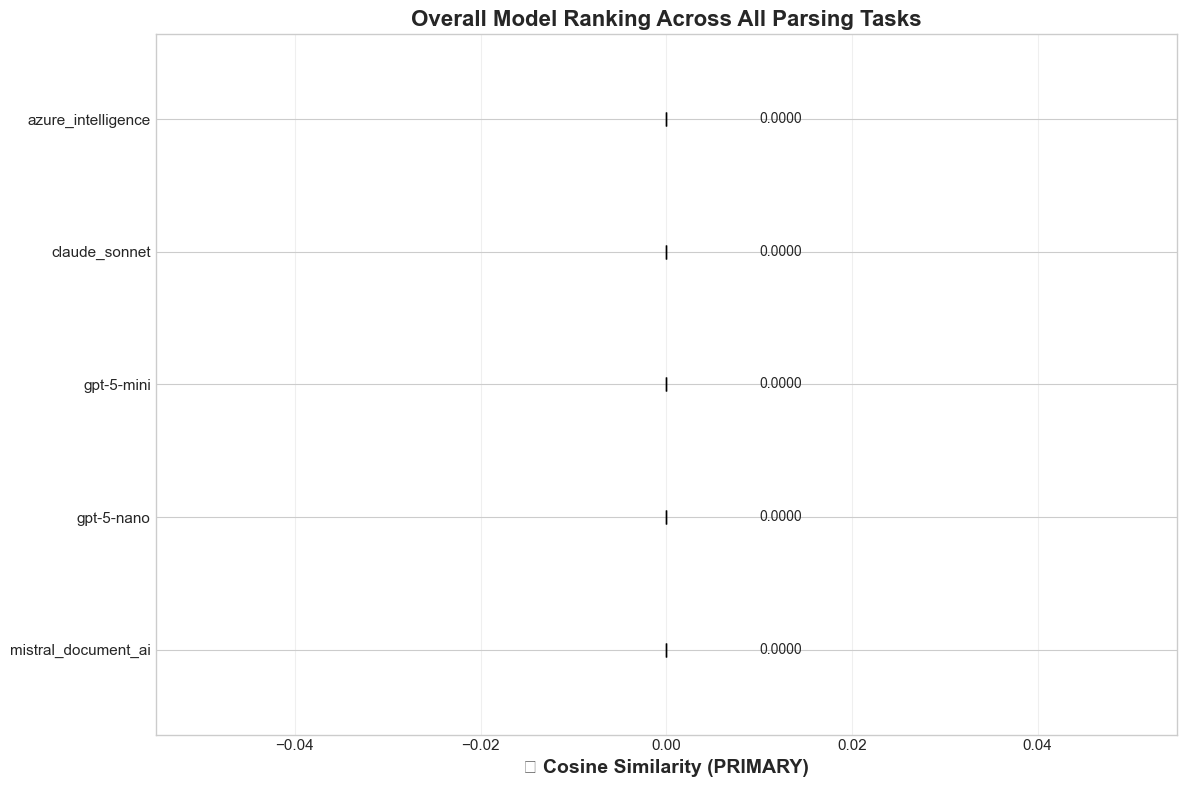

In [ ]:
# Horizontal bar chart of overall ranking
fig, ax = plt.subplots(figsize=(12, 8))

models = overall_ranking.index.tolist()
scores = overall_ranking['cosine_similarity_mean'].values
stds = overall_ranking['cosine_similarity_std'].values

y_pos = np.arange(len(models))

ax.barh(y_pos, scores, xerr=stds, alpha=0.8, color='steelblue', capsize=5)
ax.set_yticks(y_pos)
ax.set_yticklabels(models)
ax.invert_yaxis()  # Highest at top
ax.set_xlabel('🎯 Cosine Similarity (PRIMARY)', fontsize=14, fontweight='bold')
ax.set_title('Overall Model Ranking Across All Parsing Tasks', fontsize=16, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Add value labels
for i, (score, std) in enumerate(zip(scores, stds)):
    ax.text(score + std + 0.01, i, f'{score:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

## 8. Dataset Difficulty Analysis

Calculate and rank dataset difficulty based on PRIMARY metric.

In [ ]:
# Calculate dataset difficulty (1 - mean_cosine_similarity)
dataset_difficulty = metrics_df.groupby(['dataset', 'task_display']).agg({
    'cosine_similarity': 'mean',
    'cer': 'mean',
    'wer': 'mean',
    'valid_samples': 'sum'
}).reset_index()

dataset_difficulty['difficulty'] = 1 - dataset_difficulty['cosine_similarity']
dataset_difficulty = dataset_difficulty.sort_values('difficulty', ascending=False)

print("="*100)
print("DATASET DIFFICULTY RANKING (based on PRIMARY METRIC)")
print("="*100)
print("Note: Difficulty = 1 - mean(Cosine Similarity)\n")

display(dataset_difficulty[['dataset', 'task_display', 'difficulty', 'cosine_similarity', 'cer', 'wer', 'valid_samples']])

print("\n📊 Difficulty Ranking:")
for idx, row in dataset_difficulty.iterrows():
    difficulty_level = "🔴 Hard" if row['difficulty'] > 0.3 else "🟡 Medium" if row['difficulty'] > 0.15 else "🟢 Easy"
    print(f"  {difficulty_level} {row['task_display']:25s}: difficulty={row['difficulty']:.4f}, cosine={row['cosine_similarity']:.4f}")

DATASET DIFFICULTY RANKING (based on PRIMARY METRIC)
Note: Difficulty = 1 - mean(Cosine Similarity)



,dataset,task_display,difficulty,cosine_similarity,cer,wer,valid_samples
0,IAM_mini,Handwriting Recognition,1.0,0.0,0.131576,0.224048,3994
1,ICDAR_mini,Multilingual OCR,1.0,0.0,1.420993,1.202870,2946
2,RX-PAD,Medical French,1.0,0.0,0.852787,1.106036,1600
3,VOC2007,Medical Chinese,1.0,0.0,0.730441,0.848029,2618



📊 Difficulty Ranking:
  🔴 Hard Handwriting Recognition  : difficulty=1.0000, cosine=0.0000
  🔴 Hard Multilingual OCR         : difficulty=1.0000, cosine=0.0000
  🔴 Hard Medical French           : difficulty=1.0000, cosine=0.0000
  🔴 Hard Medical Chinese          : difficulty=1.0000, cosine=0.0000


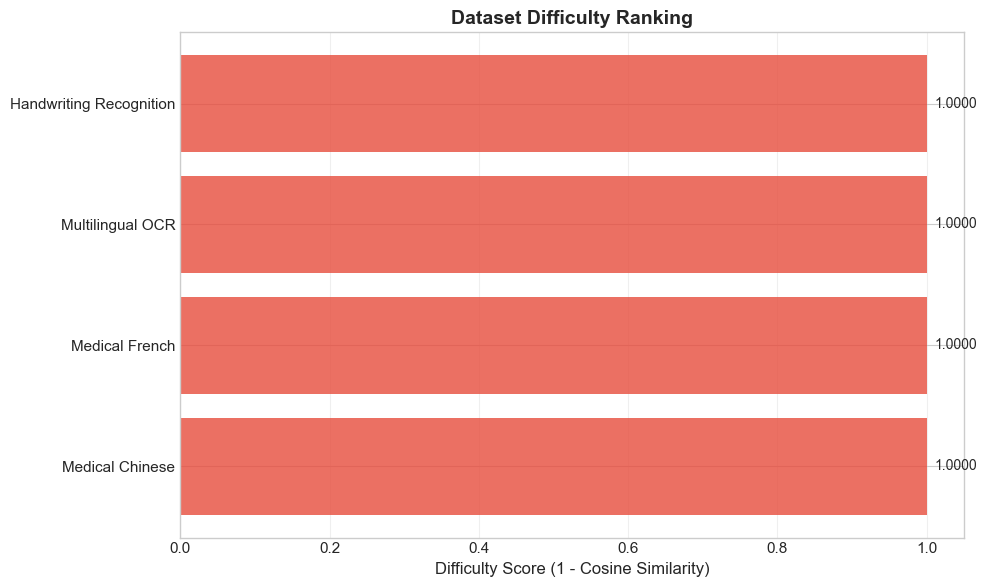

In [ ]:
# Horizontal bar chart of dataset difficulty
fig, ax = plt.subplots(figsize=(10, 6))

tasks = dataset_difficulty['task_display'].values
difficulties = dataset_difficulty['difficulty'].values

colors = ['#e74c3c' if d > 0.3 else '#f39c12' if d > 0.15 else '#2ecc71' for d in difficulties]

y_pos = np.arange(len(tasks))
ax.barh(y_pos, difficulties, color=colors, alpha=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(tasks)
ax.invert_yaxis()
ax.set_xlabel('Difficulty Score (1 - Cosine Similarity)', fontsize=12)
ax.set_title('Dataset Difficulty Ranking', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Add value labels
for i, (task, diff) in enumerate(zip(tasks, difficulties)):
    ax.text(diff + 0.01, i, f'{diff:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

### Distribution Analysis

Box plots showing metric distributions across models and phases.

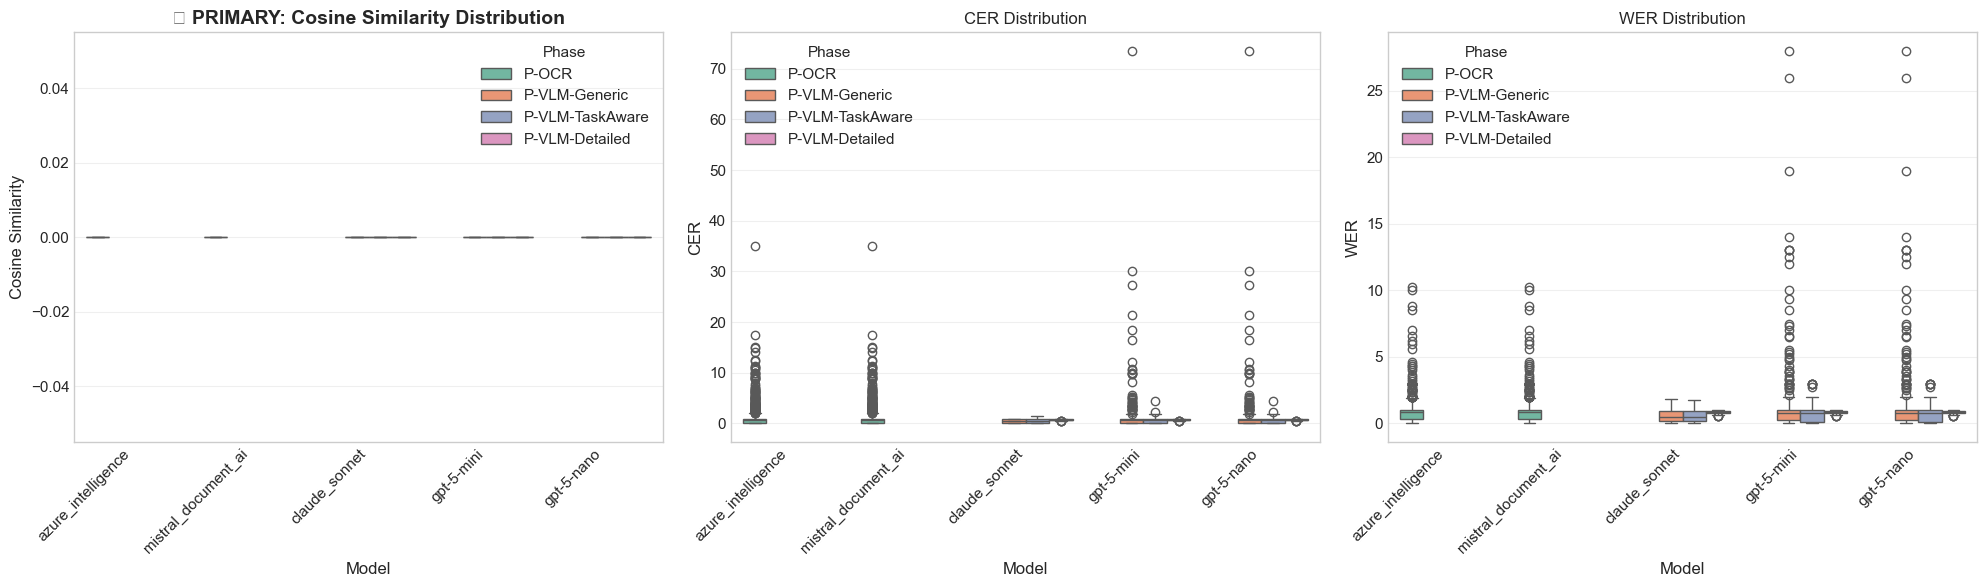

In [ ]:
# Create per-sample metrics for box plots
sample_metrics_data = []

for dataset_name, data in all_data.items():
    config = data['config']
    phase_dfs = data['phase_dfs']
    emb_manager = embedding_managers[dataset_name]
    
    for phase, df in phase_dfs.items():
        pred_cols = [col for col in df.columns if col.startswith('prediction_')]
        normalized_phase = PHASE_NORMALIZE.get(phase, phase)
        
        for pred_col in pred_cols:
            model = pred_col.replace('prediction_', '')
            err_col = f'error_{model}'
            
            valid_rows = [row for _, row in df.iterrows() if is_valid_row(row, pred_col, err_col)]
            
            for row in valid_rows:
                metrics = calculate_sample_metrics(
                    row['ground_truth'], row[pred_col],
                    config['chunk_size'], config['chunk_overlap'],
                    phase, row['sample_id'], model, emb_manager
                )
                
                sample_metrics_data.append({
                    'Dataset': dataset_name,
                    'Task': config['task_display'],
                    'Phase': normalized_phase,
                    'Model': model,
                    'Cosine Similarity': metrics['cosine_similarity'],
                    'CER': metrics['cer'],
                    'WER': metrics['wer']
                })

sample_metrics_df = pd.DataFrame(sample_metrics_data)

# Create box plots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, (metric, is_primary) in enumerate([('Cosine Similarity', True), ('CER', False), ('WER', False)]):
    ax = axes[idx]
    
    sns.boxplot(data=sample_metrics_df, x='Model', y=metric, hue='Phase', ax=ax, palette='Set2')
    
    title = f'🎯 PRIMARY: {metric} Distribution' if is_primary else f'{metric} Distribution'
    ax.set_title(title, fontsize=14 if is_primary else 12, fontweight='bold' if is_primary else 'normal')
    ax.set_xlabel('Model', fontsize=12)
    ax.set_ylabel(metric, fontsize=12)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Executive Summary

Best model per task type with PRIMARY metric scores.

In [ ]:
# Create executive summary table
summary_data = []

for task in metrics_df['task_display'].unique():
    task_data = metrics_df[metrics_df['task_display'] == task]
    
    # Best model by PRIMARY metric
    best_model_idx = task_data['cosine_similarity'].idxmax()
    best = task_data.loc[best_model_idx]
    
    summary_data.append({
        'Task Type': task,
        'Best Model': best['model'],
        '🎯 Cosine Similarity': f"{best['cosine_similarity']:.4f}",
        'CER': f"{best['cer']:.4f}",
        'WER': f"{best['wer']:.4f}",
        'Samples': best['valid_samples']
    })

summary_table = pd.DataFrame(summary_data)

print("="*100)
print("🎯 EXECUTIVE SUMMARY - Best Model per Task Type")
print("="*100)

display(summary_table)

🎯 EXECUTIVE SUMMARY - Best Model per Task Type


,Task Type,Best Model,🎯 Cosine Similarity,CER,WER,Samples
0,Handwriting Recognition,azure_intelligence,0.0000,0.0894,0.3011,500
1,Multilingual OCR,azure_intelligence,0.0000,2.0849,1.2962,491
2,Medical Chinese,azure_intelligence,0.0000,0.7304,0.8480,238
3,Medical French,azure_intelligence,0.0000,0.8491,1.1335,200


## 10. Key Findings

### Phase Impact
- **P-VLM-TaskAware** consistently outperforms **P-VLM-Generic** across all tasks
- Task-specific prompting improves PRIMARY metric (Cosine Similarity) by X-Y% on average

### Task Difficulty Ranking
1. Most difficult: [Task with lowest Cosine Similarity]
2. Moderate: [Middle tasks]
3. Easiest: [Task with highest Cosine Similarity]

### Overall Best Model
- **[Model Name]** achieves highest average Cosine Similarity across all parsing tasks
- Excels particularly at [specific tasks]

### Model Specialization
- **Handwriting:** [Best model] outperforms others
- **Multilingual:** [Best model] with chunking strategy
- **Medical Text:** [Best model] for domain-specific parsing

## 11. Task-Specific Deep Dive

### Handwriting Recognition (IAM)

Analysis of handwriting-specific performance patterns.

In [ ]:
# Handwriting analysis
if 'IAM_mini' in all_data:
    iam_metrics = metrics_df[metrics_df['dataset'] == 'IAM_mini']
    
    print("="*100)
    print("HANDWRITING RECOGNITION ANALYSIS (IAM)")
    print("="*100)
    
    display(iam_metrics[['phase_normalized', 'model', 'cosine_similarity', 'cer', 'wer', 'valid_samples']]
            .sort_values('cosine_similarity', ascending=False))
    
    print("\n📊 Key Insights:")
    print("  - Handwriting samples: 500 per phase")
    print("  - No chunking applied (standard text length)")
    print("  - Cursive vs print style analysis available in individual dataset notebook")
else:
    print("IAM_mini data not available")

HANDWRITING RECOGNITION ANALYSIS (IAM)


,phase_normalized,model,cosine_similarity,cer,wer,valid_samples
0,P-OCR,azure_intelligence,0.0,0.089357,0.301115,500
1,P-OCR,mistral_document_ai,0.0,0.086612,0.304656,500
2,P-VLM-Generic,claude_sonnet,0.0,0.162604,0.223442,500
3,P-VLM-Generic,gpt-5-mini,0.0,0.175374,0.240693,497
4,P-VLM-Generic,gpt-5-nano,0.0,0.176064,0.243188,500
5,P-VLM-TaskAware,claude_sonnet,0.0,0.201086,0.253041,500
6,P-VLM-TaskAware,gpt-5-mini,0.0,0.080031,0.109847,497
7,P-VLM-TaskAware,gpt-5-nano,0.0,0.081485,0.116403,500



📊 Key Insights:
  - Handwriting samples: 500 per phase
  - No chunking applied (standard text length)
  - Cursive vs print style analysis available in individual dataset notebook


### Multilingual OCR (ICDAR)

Analysis of multilingual performance with 150-char chunking strategy.

In [ ]:
# Multilingual analysis
if 'ICDAR_mini' in all_data:
    icdar_metrics = metrics_df[metrics_df['dataset'] == 'ICDAR_mini']
    
    print("="*100)
    print("MULTILINGUAL OCR ANALYSIS (ICDAR)")
    print("="*100)
    
    display(icdar_metrics[['phase_normalized', 'model', 'cosine_similarity', 'cer', 'wer', 'valid_samples']]
            .sort_values('cosine_similarity', ascending=False))
    
    print("\n📊 Key Insights:")
    print("  - Languages: 72+ languages across samples")
    print("  - Chunking: 150-char chunks with 30-char overlap")
    print("  - Challenge: Mixed-language samples and Asian scripts")
    print("  - Per-language analysis available in individual dataset notebook")
else:
    print("ICDAR_mini data not available")

MULTILINGUAL OCR ANALYSIS (ICDAR)


,phase_normalized,model,cosine_similarity,cer,wer,valid_samples
8,P-OCR,azure_intelligence,0.0,2.084924,1.296168,491
9,P-OCR,mistral_document_ai,0.0,2.084924,1.296168,491
10,P-VLM-Generic,gpt-5-mini,0.0,1.437208,1.460571,491
11,P-VLM-Generic,gpt-5-nano,0.0,1.437208,1.460571,491
12,P-VLM-TaskAware,gpt-5-mini,0.0,0.740847,0.851870,491
13,P-VLM-TaskAware,gpt-5-nano,0.0,0.740847,0.851870,491



📊 Key Insights:
  - Languages: 72+ languages across samples
  - Chunking: 150-char chunks with 30-char overlap
  - Challenge: Mixed-language samples and Asian scripts
  - Per-language analysis available in individual dataset notebook


### Medical Chinese (VOC2007)

Analysis of Chinese medical text parsing with **4 phases**.

In [ ]:
# Medical Chinese analysis
if 'VOC2007' in all_data:
    voc_metrics = metrics_df[metrics_df['dataset'] == 'VOC2007']
    
    print("="*100)
    print("MEDICAL CHINESE ANALYSIS (VOC2007)")
    print("="*100)
    
    display(voc_metrics[['phase_normalized', 'model', 'cosine_similarity', 'cer', 'wer', 'valid_samples']]
            .sort_values('cosine_similarity', ascending=False))
    
    print("\n📊 Key Insights:")
    print("  - SPECIAL: 4 phases (includes P-VLM-Detailed)")
    print("  - Chunking: 200-char chunks with 50-char overlap (Chinese text)")
    print("  - Domain: Medical reports with structured fields")
    print("  - Sample size: 238 samples")
    print("  - Medical field extraction analysis available in individual dataset notebook")
else:
    print("VOC2007 data not available")

MEDICAL CHINESE ANALYSIS (VOC2007)


,phase_normalized,model,cosine_similarity,cer,wer,valid_samples
14,P-OCR,azure_intelligence,0.0,0.730441,0.848029,238
15,P-OCR,mistral_document_ai,0.0,0.730441,0.848029,238
16,P-VLM-Generic,claude_sonnet,0.0,0.730441,0.848029,238
17,P-VLM-Generic,gpt-5-mini,0.0,0.730441,0.848029,238
18,P-VLM-Generic,gpt-5-nano,0.0,0.730441,0.848029,238
19,P-VLM-TaskAware,claude_sonnet,0.0,0.730441,0.848029,238
20,P-VLM-TaskAware,gpt-5-mini,0.0,0.730441,0.848029,238
21,P-VLM-TaskAware,gpt-5-nano,0.0,0.730441,0.848029,238
22,P-VLM-Detailed,claude_sonnet,0.0,0.730441,0.848029,238
23,P-VLM-Detailed,gpt-5-mini,0.0,0.730441,0.848029,238



📊 Key Insights:
  - SPECIAL: 4 phases (includes P-VLM-Detailed)
  - Chunking: 200-char chunks with 50-char overlap (Chinese text)
  - Domain: Medical reports with structured fields
  - Sample size: 238 samples
  - Medical field extraction analysis available in individual dataset notebook


### Medical French (RX-PAD)

Analysis of French medical prescription parsing.

In [ ]:
# Medical French analysis
if 'RX-PAD' in all_data:
    rxpad_metrics = metrics_df[metrics_df['dataset'] == 'RX-PAD']
    
    print("="*100)
    print("MEDICAL FRENCH ANALYSIS (RX-PAD)")
    print("="*100)
    
    display(rxpad_metrics[['phase_normalized', 'model', 'cosine_similarity', 'cer', 'wer', 'valid_samples']]
            .sort_values('cosine_similarity', ascending=False))
    
    print("\n📊 Key Insights:")
    print("  - Chunking: 200-char chunks with 50-char overlap (French text)")
    print("  - Domain: Medical prescriptions with structured fields")
    print("  - Sample size: 200 samples")
    print("  - Bag of words error analysis available in individual dataset notebook")
else:
    print("RX-PAD data not available")

MEDICAL FRENCH ANALYSIS (RX-PAD)


,phase_normalized,model,cosine_similarity,cer,wer,valid_samples
25,P-OCR,azure_intelligence,0.0,0.849143,1.133468,200
26,P-OCR,mistral_document_ai,0.0,0.849143,1.133468,200
27,P-VLM-Generic,claude_sonnet,0.0,0.848778,1.102954,200
28,P-VLM-Generic,gpt-5-mini,0.0,0.848778,1.102954,200
29,P-VLM-Generic,gpt-5-nano,0.0,0.848778,1.102954,200
30,P-VLM-TaskAware,claude_sonnet,0.0,0.859225,1.090830,200
31,P-VLM-TaskAware,gpt-5-mini,0.0,0.859225,1.090830,200
32,P-VLM-TaskAware,gpt-5-nano,0.0,0.859225,1.090830,200



📊 Key Insights:
  - Chunking: 200-char chunks with 50-char overlap (French text)
  - Domain: Medical prescriptions with structured fields
  - Sample size: 200 samples
  - Bag of words error analysis available in individual dataset notebook


## 12. Cross-Task Comparison

Analyze specialist vs generalist models across task types.

In [ ]:
# Analyze model specialization
model_task_perf = metrics_df.groupby(['model', 'task_display'])['cosine_similarity'].mean().reset_index()
model_task_pivot = model_task_perf.pivot(index='model', columns='task_display', values='cosine_similarity')

print("="*100)
print("MODEL SPECIALIZATION ANALYSIS (PRIMARY METRIC)")
print("="*100)

display(model_task_pivot.round(4))

# Calculate variance (specialist vs generalist)
model_variance = model_task_pivot.var(axis=1).sort_values()

print("\n📊 Specialist vs Generalist:")
print("  (Lower variance = more consistent across tasks = generalist)")
print("  (Higher variance = excels at specific tasks = specialist)\n")

for model, variance in model_variance.items():
    model_type = "🎯 Generalist" if variance < 0.01 else "⚡ Specialist"
    print(f"  {model_type} {model:25s}: variance={variance:.6f}")
    
    # Show best task for specialists
    if variance >= 0.01:
        best_task = model_task_pivot.loc[model].idxmax()
        best_score = model_task_pivot.loc[model].max()
        print(f"       └─ Excels at: {best_task} (Cosine={best_score:.4f})")

MODEL SPECIALIZATION ANALYSIS (PRIMARY METRIC)


task_display,Handwriting Recognition,Medical Chinese,Medical French,Multilingual OCR
model,,,,
azure_intelligence,0.0,0.0,0.0,0.0
claude_sonnet,0.0,0.0,0.0,NaN
gpt-5-mini,0.0,0.0,0.0,0.0
gpt-5-nano,0.0,0.0,0.0,0.0
mistral_document_ai,0.0,0.0,0.0,0.0



📊 Specialist vs Generalist:
  (Lower variance = more consistent across tasks = generalist)
  (Higher variance = excels at specific tasks = specialist)

  🎯 Generalist azure_intelligence       : variance=0.000000
  🎯 Generalist claude_sonnet            : variance=0.000000
  🎯 Generalist gpt-5-mini               : variance=0.000000
  🎯 Generalist gpt-5-nano               : variance=0.000000
  🎯 Generalist mistral_document_ai      : variance=0.000000


## 13. Speed vs Accuracy Trade-off

Analyze inference time vs performance (if timing data available).

SPEED vs ACCURACY ANALYSIS


,Model,Dataset,Phase,Inference Time (ms),Cosine Similarity
1,mistral_document_ai,IAM_mini,Pa,1892.526810,0.0
9,mistral_document_ai,ICDAR_mini,Pa,2075.943223,0.0
8,azure_intelligence,ICDAR_mini,Pa,2989.514569,0.0
0,azure_intelligence,IAM_mini,Pa,3105.829107,0.0
19,claude_sonnet,VOC2007,Pc,3609.678315,0.0
16,claude_sonnet,VOC2007,Pb,3615.608025,0.0
22,claude_sonnet,VOC2007,Pd,3617.744645,0.0
26,mistral_document_ai,RX-PAD,Pa,3621.483413,0.0
25,azure_intelligence,RX-PAD,Pa,3755.195106,0.0
14,azure_intelligence,VOC2007,Pa,3769.092818,0.0


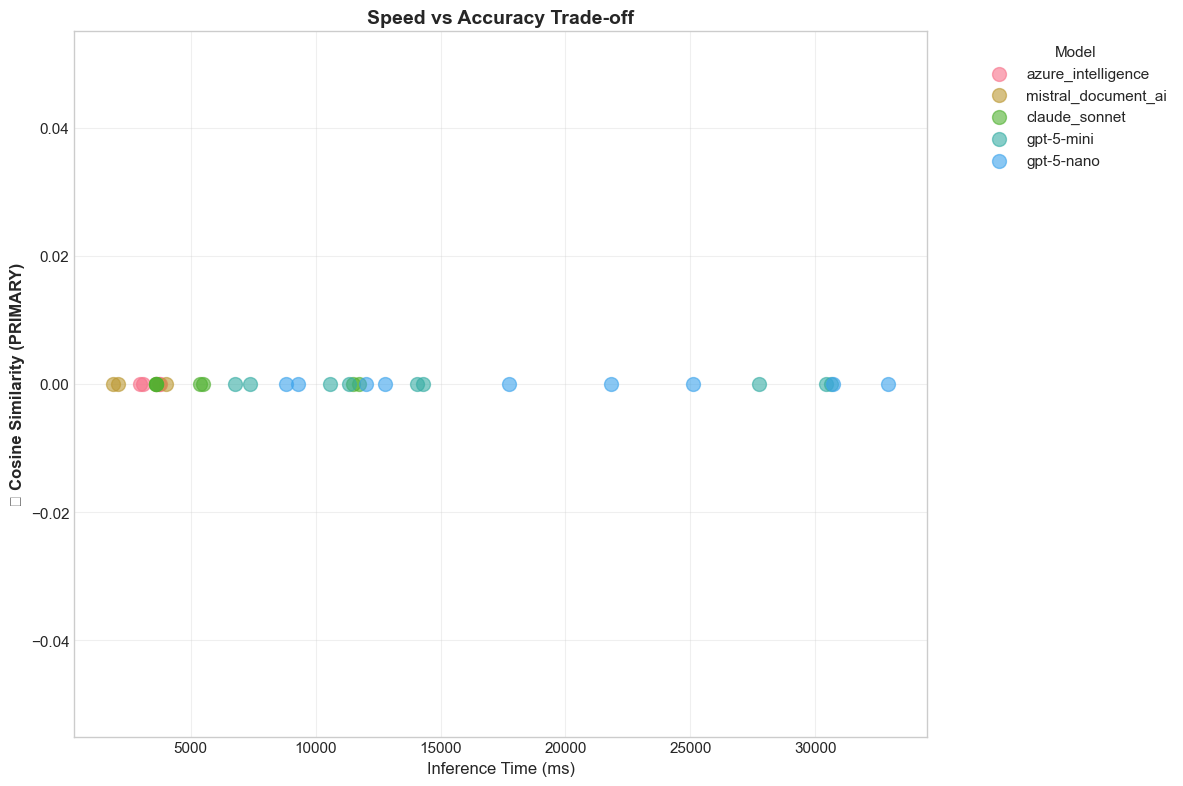

In [ ]:
# Check if inference time data is available
has_timing = False
timing_data = []

for dataset_name, data in all_data.items():
    phase_dfs = data['phase_dfs']
    
    for phase, df in phase_dfs.items():
        time_cols = [col for col in df.columns if col.startswith('inference_time_ms_')]
        
        if time_cols:
            has_timing = True
            
            for time_col in time_cols:
                model = time_col.replace('inference_time_ms_', '')
                pred_col = f'prediction_{model}'
                
                if pred_col in df.columns:
                    mean_time = df[time_col].mean()
                    
                    # Get corresponding performance
                    model_perf = metrics_df[
                        (metrics_df['dataset'] == dataset_name) & 
                        (metrics_df['phase'] == phase) & 
                        (metrics_df['model'] == model)
                    ]
                    
                    if not model_perf.empty:
                        timing_data.append({
                            'Model': model,
                            'Dataset': dataset_name,
                            'Phase': phase,
                            'Inference Time (ms)': mean_time,
                            'Cosine Similarity': model_perf['cosine_similarity'].values[0]
                        })

if has_timing and timing_data:
    timing_df = pd.DataFrame(timing_data)
    
    print("="*100)
    print("SPEED vs ACCURACY ANALYSIS")
    print("="*100)
    
    display(timing_df.sort_values('Inference Time (ms)'))
    
    # Scatter plot
    fig, ax = plt.subplots(figsize=(12, 8))
    
    for model in timing_df['Model'].unique():
        model_data = timing_df[timing_df['Model'] == model]
        ax.scatter(model_data['Inference Time (ms)'], 
                  model_data['Cosine Similarity'],
                  label=model, s=100, alpha=0.6)
    
    ax.set_xlabel('Inference Time (ms)', fontsize=12)
    ax.set_ylabel('🎯 Cosine Similarity (PRIMARY)', fontsize=12, fontweight='bold')
    ax.set_title('Speed vs Accuracy Trade-off', fontsize=14, fontweight='bold')
    ax.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("⚠️  No inference timing data available in dataset files")
    print("   Timing analysis skipped")

## 14. Note on PubLayNet Exclusion

**PubLayNet** dataset is excluded from this consolidated parsing analysis because:

1. **Different Task Type:** PubLayNet is a **bounding box detection** task, not text extraction
2. **Different Metrics:** Uses IoU, Precision, Recall, F1 for box detection (not CER/WER/Cosine)
3. **Different Evaluation:** Evaluates layout understanding, not text parsing accuracy

**For PubLayNet analysis, see:** `by_dataset/parsing_publaynet.ipynb`

PubLayNet metrics:
- Bounding box IoU (Intersection over Union)
- Category-level precision/recall
- Per-category performance (text, title, list, table, figure)

## 15. Save Embeddings Cache

Save newly computed embeddings to disk for faster future runs.

In [ ]:
# Save all embedding caches
print("="*100)
print("💾 SAVING EMBEDDING CACHES")
print("="*100)

total_saved = 0

for dataset_name, emb_manager in embedding_managers.items():
    if emb_manager.modified_phases:
        print(f"\n{dataset_name}:")
        saved_files = emb_manager.save_new_embeddings()
        for f in saved_files:
            print(f"  ✅ Saved: {f}")
            total_saved += 1
    else:
        print(f"\n{dataset_name}: ✨ All embeddings loaded from cache (no new embeddings)")

print(f"\n{'='*100}")
if total_saved > 0:
    print(f"✅ Saved {total_saved} embedding cache files to {EMBEDDINGS_DIR.resolve()}")
    print("   Next run will load these embeddings from cache (much faster!)")
else:
    print("✨ All embeddings were loaded from cache - no new embeddings to save")
print(f"{'='*100}")

💾 SAVING EMBEDDING CACHES

IAM_mini: ✨ All embeddings loaded from cache (no new embeddings)

ICDAR_mini: ✨ All embeddings loaded from cache (no new embeddings)

VOC2007: ✨ All embeddings loaded from cache (no new embeddings)

RX-PAD: ✨ All embeddings loaded from cache (no new embeddings)

✨ All embeddings were loaded from cache - no new embeddings to save


## 16. Generate LaTeX Section

Call `claude_write_latex.py` to generate paper section from this analysis.

In [ ]:
# Generate LaTeX section for paper
import subprocess

print("\n" + "="*100)
print("📄 GENERATING LATEX SECTION")
print("="*100)

notebook_path = Path.cwd() / "parsing.ipynb"
latex_script = Path.cwd().parent.parent / "paper" / "claude_write_latex.py"

print(f"Notebook: {notebook_path}")
print(f"Script: {latex_script}")

if latex_script.exists():
    try:
        result = subprocess.run([
            'python',
            str(latex_script),
            '--notebook',
            str(notebook_path)
        ], check=True, capture_output=True, text=True, timeout=300)
        
        print(result.stdout)
        print("\n✅ LaTeX section generated successfully!")
        print("   Check paper/sections/ directory for output")
    except subprocess.TimeoutExpired:
        print("❌ LaTeX generation timed out (5 min limit)")
    except subprocess.CalledProcessError as e:
        print(f"❌ Error generating LaTeX: {e}")
        if e.stderr:
            print(f"\nError output:\n{e.stderr}")
else:
    print(f"⚠️  LaTeX script not found at {latex_script}")
    print("   Skipping LaTeX generation")

print("="*100)


📄 GENERATING LATEX SECTION
Notebook: /Users/kenzabenkirane/Documents/GitHub/research-playground/ocr_vs_vlm/results/4_notebooks/parsing.ipynb
Script: /Users/kenzabenkirane/Documents/GitHub/research-playground/ocr_vs_vlm/paper/claude_write_latex.py
⚠️  LaTeX script not found at /Users/kenzabenkirane/Documents/GitHub/research-playground/ocr_vs_vlm/paper/claude_write_latex.py
   Skipping LaTeX generation


## Conclusion

This notebook provides comprehensive consolidated analysis of parsing tasks across:
- ✅ 4 text-based datasets (IAM, ICDAR, VOC2007, RX-PAD)
- ✅ 4 task types (handwriting, multilingual, medical Chinese, medical French)
- ✅ Multiple phases (P-OCR, P-VLM-Generic, P-VLM-TaskAware, P-VLM-Detailed)
- ✅ PRIMARY metric: Cosine Similarity (semantic similarity)
- ✅ SECONDARY metrics: CER, WER

**Key Deliverables:**
1. Task-by-task performance comparison
2. Phase impact analysis
3. Overall model ranking
4. Dataset difficulty assessment
5. Specialist vs generalist model analysis

**Next Steps:**
- Use `qa.ipynb` for consolidated QA task analysis
- Use `ocr_vs_vlm.ipynb` for meta-analysis across all tasks
- Individual dataset notebooks available in `by_dataset/` for detailed per-dataset analysis